# Day 13: Restaurant Branch Performance EDA

This notebook explores restaurant performance using descriptive statistics, distributions, group comparisons, and numerical correlations.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

source_path = Path(r'c:\Users\HP\Searches\Internship\Day13_Restaurant_Branch_Performance_Dataset.csv')
df = pd.read_csv(source_path, parse_dates=['Date'])
print(f'Rows: {df.shape[0]}, columns: {df.shape[1]}')
display(df.head())
display(df.dtypes.to_frame('data_type'))
print('Duplicate rows:', df.duplicated().sum())
print('Missing values:', int(df.isnull().sum().sum()))

Rows: 350, columns: 22


,Record_ID,Date,Day,Month,Branch,Region,Store_Type,Staff_Count,Marketing_Spend,Customers,...,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent,Weather,Promotion
0,ST0001,2026-06-06,Saturday,June,Jaipur,North,Express,7,4977.25,172,...,66766.77,27954.29,46554.90,20211.87,29.0,4.44,20.8,70.3,Clear,NaN
1,ST0002,2026-02-10,Tuesday,February,Pune,West,Premium,14,8998.30,285,...,157230.89,63816.59,96813.95,60416.94,27.9,4.56,31.3,70.7,Clear,Loyalty Offer
2,ST0003,2026-03-07,Saturday,March,Delhi,North,Premium,16,10034.97,306,...,155811.96,54874.10,89888.91,65923.05,30.2,4.36,21.4,61.5,Clear,NaN
3,ST0004,2026-05-11,Monday,May,Mumbai,West,Standard,9,5095.84,198,...,80574.05,31429.44,53531.82,27042.23,21.7,4.65,22.9,40.4,Clear,NaN
4,ST0005,2026-01-14,Wednesday,January,Kochi,South,Express,9,6681.82,148,...,56579.89,21759.51,44376.25,12203.64,26.1,4.50,29.0,44.3,Clear,Combo Deal


,data_type
Record_ID,object
Date,datetime64[ns]
Day,object
Month,object
Branch,object
Region,object
Store_Type,object
Staff_Count,int64
Marketing_Spend,float64
Customers,int64


Duplicate rows: 0
Missing values: 184


## Summary statistics and descriptive analysis

In [2]:
numeric_columns = df.select_dtypes(include='number').columns.tolist()
display(df[numeric_columns].describe().T.round(2))

print('Category counts:')
for column in ['Branch', 'Region', 'Store_Type', 'Weather', 'Promotion']:
    print(f'\n{column}')
    display(df[column].value_counts().to_frame('count'))

key_metrics = ['Customers', 'Orders', 'Revenue', 'Profit', 'Marketing_Spend', 'Staff_Count', 'Avg_Delivery_Min', 'Customer_Rating']
display(df[key_metrics].agg(['mean', 'median', 'std']).T.round(2))

,count,mean,std,min,25%,50%,75%,max
Staff_Count,350.0,11.96,4.34,5.00,9.00,11.00,15.00,24.00
Marketing_Spend,350.0,5516.35,2050.91,725.35,4339.73,5393.37,6748.50,11784.96
Customers,350.0,217.38,56.72,77.00,180.25,213.00,255.75,360.00
Orders,350.0,187.05,50.56,71.00,155.00,182.50,218.75,334.00
Average_Bill,350.0,388.91,82.49,180.00,337.32,383.48,441.76,623.28
Revenue,350.0,86831.80,36644.45,20540.76,61261.72,79766.88,102976.18,194018.92
Food_Cost,350.0,31807.55,13896.89,7262.01,22326.66,28861.32,38370.37,75946.59
Operating_Cost,350.0,56621.44,18467.84,20782.38,43797.67,53723.02,63961.23,111489.14
Profit,350.0,30210.36,19508.59,-6924.68,16915.49,26873.87,39823.74,89096.19
Avg_Delivery_Min,350.0,26.10,4.39,13.90,22.80,26.10,29.08,38.30


Category counts:

Branch


,count
Branch,
Srinagar,52
Jaipur,48
Kochi,48
Bengaluru,46
Mumbai,44
Hyderabad,43
Pune,37
Delhi,32



Region


,count
Region,
South,137
North,132
West,81


...


Weather


,count
Weather,
Clear,189
Cloudy,82
Rain,48
Hot,31



Promotion


,count
Promotion,
Weekend Offer,74
Combo Deal,59
Loyalty Offer,33


,mean,median,std
Customers,217.38,213.00,56.72
Orders,187.05,182.50,50.56
Revenue,86831.80,79766.88,36644.45
Profit,30210.36,26873.87,19508.59
Marketing_Spend,5516.35,5393.37,2050.91
Staff_Count,11.96,11.00,4.34
Avg_Delivery_Min,26.10,26.10,4.39
Customer_Rating,4.47,4.47,0.20


## Distribution analysis

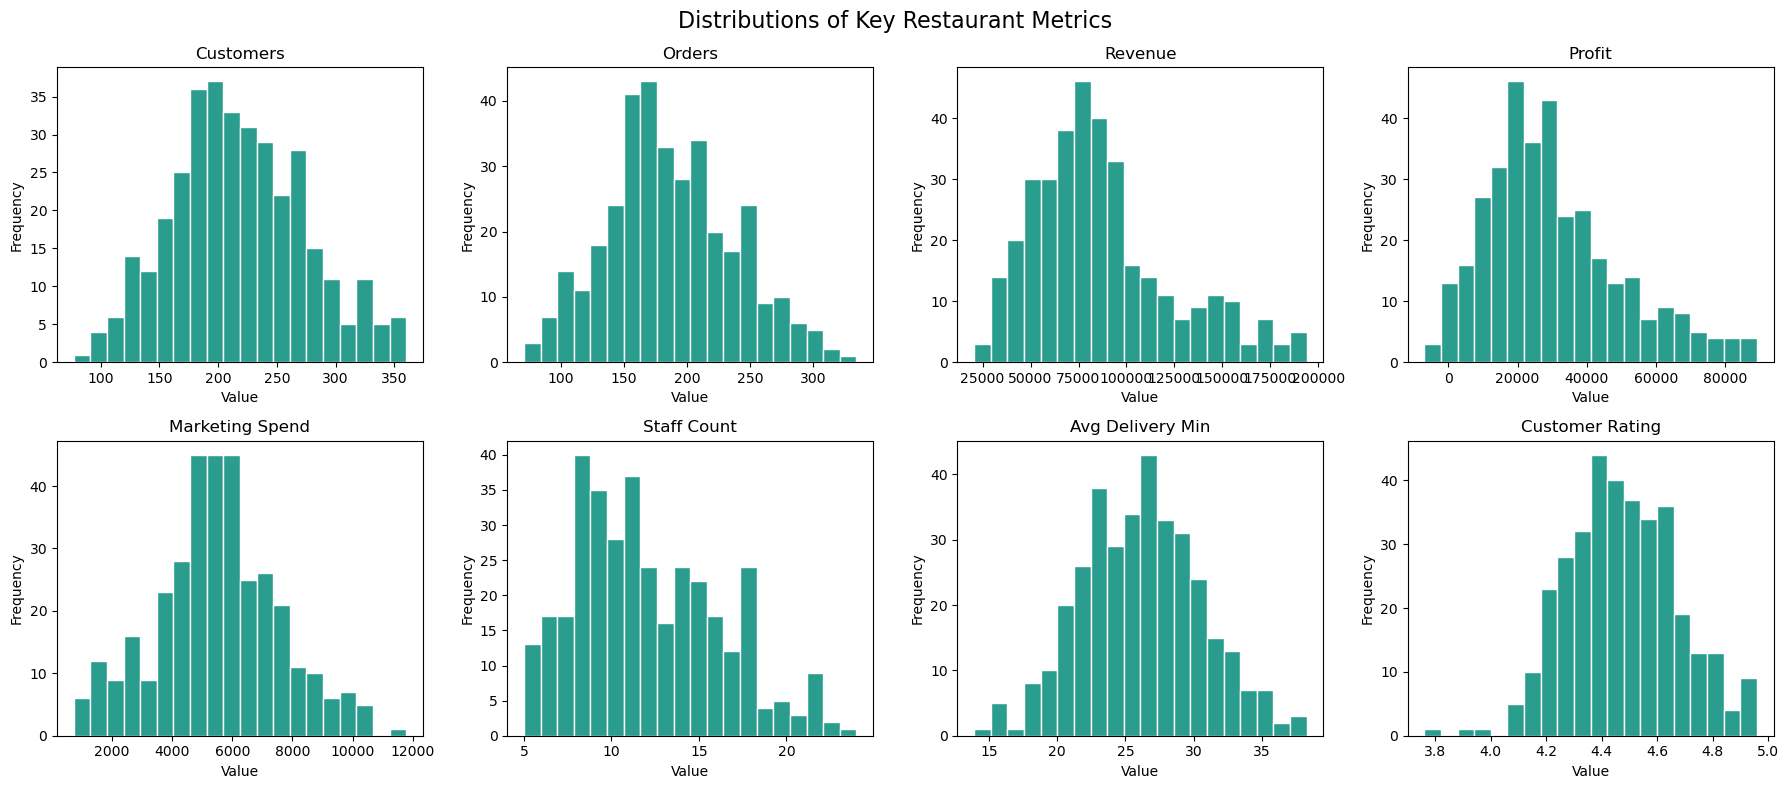

,skewness
Revenue,0.86
Profit,0.81
Staff_Count,0.53
Orders,0.27
Customers,0.23
Avg_Delivery_Min,0.14
Marketing_Spend,0.10
Customer_Rating,0.07


In [3]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for axis, column in zip(axes.flat, key_metrics):
    axis.hist(df[column], bins=20, color='#2a9d8f', edgecolor='white')
    axis.set_title(column.replace('_', ' '))
    axis.set_xlabel('Value')
    axis.set_ylabel('Frequency')
plt.suptitle('Distributions of Key Restaurant Metrics', fontsize=16)
plt.tight_layout()
plt.show()

display(df[key_metrics].skew().sort_values(ascending=False).to_frame('skewness').round(2))

## Branch, region, and store-type comparisons

Average performance by Branch:


,Customers,Orders,Revenue,Profit,Marketing_Spend,Staff_Count,Avg_Delivery_Min,Customer_Rating
Branch,,,,,,,,
Bengaluru,227.50,195.11,90732.12,31890.91,5413.93,12.85,26.56,4.47
Hyderabad,220.79,189.12,88804.90,31402.98,5455.15,12.28,25.52,4.47
Delhi,213.97,184.22,87573.87,31385.30,5762.63,11.56,25.69,4.49
Pune,214.92,187.97,88107.49,31265.57,5590.57,11.86,25.53,4.54
Jaipur,223.27,193.56,86746.16,30469.70,5356.64,11.71,26.58,4.47
Srinagar,214.73,183.17,86746.47,30302.92,5413.67,12.46,25.97,4.48
Kochi,209.06,181.46,85574.62,28902.04,5660.43,11.83,25.84,4.42
Mumbai,213.77,181.50,80779.25,26580.99,5580.10,10.89,26.86,4.44


Average performance by Region:


,Customers,Orders,Revenue,Profit,Marketing_Spend,Staff_Count,Avg_Delivery_Min,Customer_Rating
Region,,,,,,,,
South,218.93,188.45,88320.22,30690.57,5513.23,12.31,25.98,4.45
North,217.65,187.20,86946.94,30625.96,5477.53,11.97,26.13,4.48
West,214.30,184.46,84126.72,28720.86,5584.88,11.33,26.25,4.49


Average performance by Store_Type:


,Customers,Orders,Revenue,Profit,Marketing_Spend,Staff_Count,Avg_Delivery_Min,Customer_Rating
Store_Type,,,,,,,,
Premium,298.73,258.10,152867.31,62890.24,8065.56,17.60,26.40,4.46
Standard,224.98,193.77,87268.67,30630.79,5044.90,12.54,25.98,4.47
Express,161.29,137.94,52327.16,12742.14,5122.66,7.96,26.17,4.46


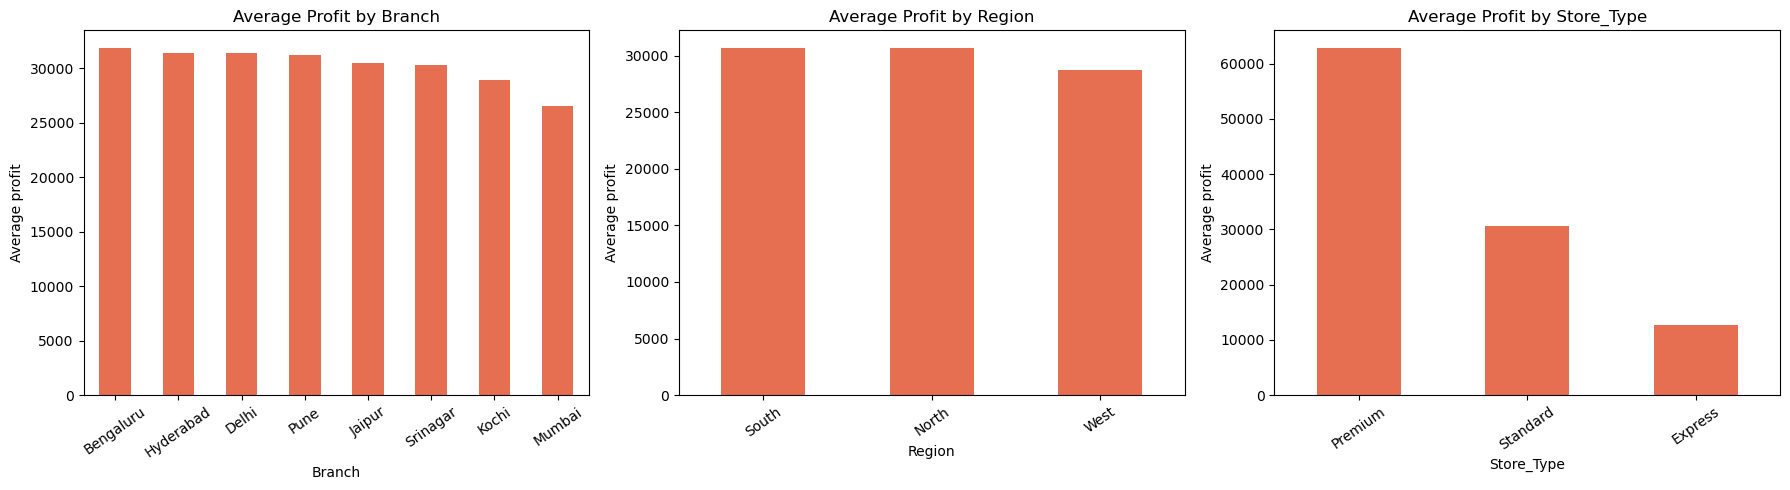

In [4]:
def performance_table(group_column):
    return (df.groupby(group_column)[key_metrics]
            .agg({'Customers': 'mean', 'Orders': 'mean', 'Revenue': 'mean',
                 'Profit': 'mean', 'Marketing_Spend': 'mean',
                 'Staff_Count': 'mean', 'Avg_Delivery_Min': 'mean',
                 'Customer_Rating': 'mean'})
            .sort_values('Profit', ascending=False).round(2))

for group_column in ['Branch', 'Region', 'Store_Type']:
    print(f'Average performance by {group_column}:')
    display(performance_table(group_column))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for axis, group_column in zip(axes, ['Branch', 'Region', 'Store_Type']):
    performance_table(group_column)['Profit'].plot(kind='bar', ax=axis, color='#e76f51')
    axis.set_title(f'Average Profit by {group_column}')
    axis.set_ylabel('Average profit')
    axis.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

## Correlation analysis

,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent
Staff_Count,1.00,0.28,0.69,0.67,0.52,0.70,0.68,0.79,0.56,-0.18,0.08,0.08,-0.02
Marketing_Spend,0.28,1.00,0.41,0.42,0.33,0.43,0.40,0.49,0.35,0.10,-0.06,0.06,-0.05
Customers,0.69,0.41,1.00,0.98,0.53,0.88,0.84,0.86,0.84,0.18,-0.05,0.00,-0.10
Orders,0.67,0.42,0.98,1.00,0.52,0.86,0.83,0.84,0.82,0.19,-0.05,0.02,-0.09
Average_Bill,0.52,0.33,0.53,0.52,1.00,0.84,0.84,0.80,0.83,-0.03,0.04,-0.05,-0.04
Revenue,0.70,0.43,0.88,0.86,0.84,1.00,0.98,0.96,0.97,0.08,0.01,-0.03,-0.09
Food_Cost,0.68,0.40,0.84,0.83,0.84,0.98,1.00,0.97,0.92,0.08,0.00,-0.03,-0.08
Operating_Cost,0.79,0.49,0.86,0.84,0.80,0.96,0.97,1.00,0.86,0.02,0.02,0.01,-0.07
Profit,0.56,0.35,0.84,0.82,0.83,0.97,0.92,0.86,1.00,0.13,-0.01,-0.06,-0.11
Avg_Delivery_Min,-0.18,0.10,0.18,0.19,-0.03,0.08,0.08,0.02,0.13,1.00,-0.44,0.00,-0.11


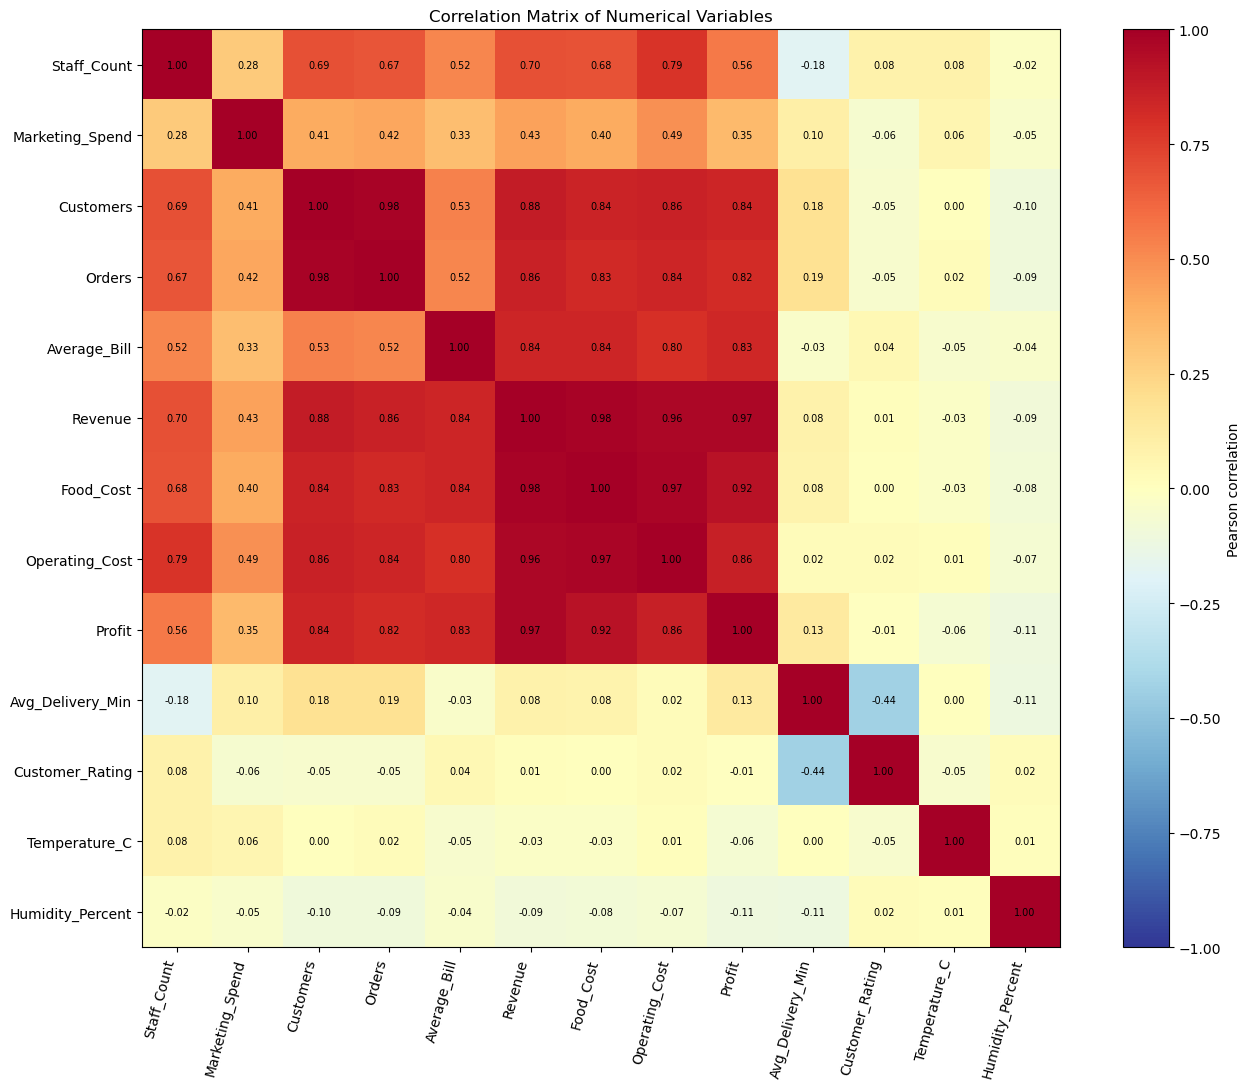

,correlation_with_profit
Revenue,0.97
Food_Cost,0.92
Operating_Cost,0.86
Customers,0.84
Average_Bill,0.83
Orders,0.82
Staff_Count,0.56
Marketing_Spend,0.35
Avg_Delivery_Min,0.13
Humidity_Percent,-0.11


In [5]:
correlation_matrix = df[numeric_columns].corr()
display(correlation_matrix.round(2))

fig, axis = plt.subplots(figsize=(14, 11))
image = axis.imshow(correlation_matrix, cmap='RdYlBu_r', vmin=-1, vmax=1)
axis.set_xticks(range(len(numeric_columns)), numeric_columns, rotation=75, ha='right')
axis.set_yticks(range(len(numeric_columns)), numeric_columns)
for row in range(len(numeric_columns)):
    for column in range(len(numeric_columns)):
        axis.text(column, row, f'{correlation_matrix.iloc[row, column]:.2f}', ha='center', va='center', fontsize=7)
fig.colorbar(image, ax=axis, label='Pearson correlation')
axis.set_title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

target_correlations = correlation_matrix['Profit'].drop('Profit').sort_values(key=abs, ascending=False)
display(target_correlations.to_frame('correlation_with_profit').round(2))

## Data-driven observations

In [6]:
branch_profit = performance_table('Branch')['Profit']
region_profit = performance_table('Region')['Profit']
store_profit = performance_table('Store_Type')['Profit']
best_branch = branch_profit.idxmax()
worst_branch = branch_profit.idxmin()
best_region = region_profit.idxmax()
best_store = store_profit.idxmax()
profit_corr = target_correlations
strongest_profit_factor = profit_corr.index[0]
strongest_profit_value = profit_corr.iloc[0]
customers_orders_corr = df[['Customers', 'Orders']].corr().iloc[0, 1]
strongest_profit_factor_label = strongest_profit_factor.replace('_', ' ')

observations = [
    f'1. {best_branch} has the highest average profit ({branch_profit.max():,.2f}), while {worst_branch} has the lowest ({branch_profit.min():,.2f}), showing meaningful branch-level variation.',
    f'2. The {best_region} region leads regional average profit at {region_profit.max():,.2f}, indicating geographic differences in performance.',
    f'3. {best_store} stores have the highest average profit among store types ({store_profit.max():,.2f}).',
    f'4. Average revenue is {df.Revenue.mean():,.2f}, compared with average profit of {df.Profit.mean():,.2f}; the gap reflects food and operating costs.',
    f'5. {strongest_profit_factor_label} has the strongest correlation with profit ({strongest_profit_value:.2f}) among the measured numerical variables.',
    f'6. Customers and orders are strongly associated (r = {customers_orders_corr:.2f}), suggesting higher customer volume generally translates into more orders.',
    f'7. Average customer rating is {df.Customer_Rating.mean():.2f}/5 and average delivery time is {df.Avg_Delivery_Min.mean():.2f} minutes; comparing their distributions helps identify service-quality patterns alongside financial performance.'
]
for observation in observations:
    print(observation)

1. Bengaluru has the highest average profit (31,890.91), while Mumbai has the lowest (26,580.99), showing meaningful branch-level variation.
2. The South region leads regional average profit at 30,690.57, indicating geographic differences in performance.
3. Premium stores have the highest average profit among store types (62,890.24).
4. Average revenue is 86,831.80, compared with average profit of 30,210.36; the gap reflects food and operating costs.
5. Revenue has the strongest correlation with profit (0.97) among the measured numerical variables.
6. Customers and orders are strongly associated (r = 0.98), suggesting higher customer volume generally translates into more orders.
7. Average customer rating is 4.47/5 and average delivery time is 26.10 minutes; comparing their distributions helps identify service-quality patterns alongside financial performance.
